NumPy Row Mean and Binary Matrix

In [1]:
import numpy as np

A = np.array([
    [12, 5, 8, 20],
    [7, 15, 3, 11],
    [25, 9, 18, 6],
    [10, 14, 2, 16]
])

# 1. Mean of each row
row_means = np.mean(A, axis=1)

print("Row means:")
print(row_means)

# 2, 3, 4. Compare every element with its row mean
binary_matrix = (A > row_means[:, np.newaxis]).astype(int)

print("\nBinary matrix:")
print(binary_matrix)

# 5. Number of elements above row mean
count_above_mean = np.sum(binary_matrix, axis=1)

print("\nNumber of elements above row mean:")
print(count_above_mean)

max_count = np.max(count_above_mean)

rows = np.where(count_above_mean == max_count)[0]

print("\nMaximum number of elements above mean:", max_count)
print("Rows:", rows + 1)

Row means:
[11.25  9.   14.5  10.5 ]

Binary matrix:
[[1 0 0 1]
 [0 1 0 1]
 [1 0 1 0]
 [0 1 0 1]]

Number of elements above row mean:
[2 2 2 2]

Maximum number of elements above mean: 2
Rows: [1 2 3 4]


Detect and Replace Outliers

In [2]:
import numpy as np

X = np.array([
    [10, 100, 5],
    [12, 110, 6],
    [11, 105, 7],
    [13, 500, 6],
    [14, 108, 8],
    [15, 115, 9]
])

# Column-wise mean
mean = np.mean(X, axis=0)

# Column-wise standard deviation
std = np.std(X, axis=0)

# Column-wise median
median = np.median(X, axis=0)

print("Mean:")
print(mean)

print("\nStandard deviation:")
print(std)

print("\nMedian:")
print(median)

# Detect outliers
outlier_mask = np.abs(X - mean) > 2 * std

print("\nOutlier mask:")
print(outlier_mask)

# Replace outliers with column median
X_clean = X.copy()

X_clean[outlier_mask] = np.broadcast_to(
    median,
    X.shape
)[outlier_mask]

print("\nCleaned data:")
print(X_clean)

Mean:
[ 12.5        173.           6.83333333]

Standard deviation:
[  1.70782513 146.31017281   1.34370962]

Median:
[ 12.5 109.    6.5]

Outlier mask:
[[False False False]
 [False False False]
 [False False False]
 [False  True False]
 [False False False]
 [False False False]]

Cleaned data:
[[ 10 100   5]
 [ 12 110   6]
 [ 11 105   7]
 [ 13 109   6]
 [ 14 108   8]
 [ 15 115   9]]


Pandas Grouping and Filtering

In [3]:
import pandas as pd

df = pd.DataFrame({
    'Student': ['A','B','C','D','E','F','G','H'],
    'Department': ['CSE','CSE','ECE','ECE','CSE','ECE','CSE','ECE'],
    'Gender': ['F','M','F','M','M','F','F','M'],
    'Marks': [85,72,91,65,78,88,95,70],
    'Attendance': [92,81,96,72,85,90,98,75]
})

# 1. Average marks for each department
dept_avg_marks = df.groupby('Department')['Marks'].mean()

print("1. Average marks by department:")
print(dept_avg_marks)


# 2. Average marks for each Department + Gender
group_avg = df.groupby(
    ['Department', 'Gender']
)['Marks'].mean()

print("\n2. Average marks by Department and Gender:")
print(group_avg)


# 3. Student with highest marks in each department
top_students = df.loc[
    df.groupby('Department')['Marks'].idxmax()
]

print("\n3. Highest marks in each department:")
print(top_students)


# 4. Students whose marks are above department average
department_average = df.groupby(
    'Department'
)['Marks'].transform('mean')

above_average = df[
    df['Marks'] > department_average
]

print("\n4. Students above department average:")
print(above_average)


# 5. Department with highest average attendance
attendance_avg = df.groupby(
    'Department'
)['Attendance'].mean()

print("\n5. Average attendance:")
print(attendance_avg)

print(
    "\nDepartment with highest average attendance:",
    attendance_avg.idxmax()
)

1. Average marks by department:
Department
CSE    82.5
ECE    78.5
Name: Marks, dtype: float64

2. Average marks by Department and Gender:
Department  Gender
CSE         F         90.0
            M         75.0
ECE         F         89.5
            M         67.5
Name: Marks, dtype: float64

3. Highest marks in each department:
  Student Department Gender  Marks  Attendance
6       G        CSE      F     95          98
2       C        ECE      F     91          96

4. Students above department average:
  Student Department Gender  Marks  Attendance
0       A        CSE      F     85          92
2       C        ECE      F     91          96
5       F        ECE      F     88          90
6       G        CSE      F     95          98

5. Average attendance:
Department
CSE    89.00
ECE    83.25
Name: Attendance, dtype: float64

Department with highest average attendance: CSE


Duplicate IDs and Data Cleaning

In [4]:
import pandas as pd

df = pd.DataFrame({
    'ID': [101,102,103,101,104,102,105],
    'Name': ['A','B','C','A','D','B','E'],
    'Age': [20,21,22,20,23,21,24],
    'Score': [80,75,90,85,88,75,92]
})

# 1. Identify duplicated IDs
duplicated_ids = df[
    df['ID'].duplicated(keep=False)
]

print("Duplicated IDs:")
print(duplicated_ids)


# 2. Check whether records are identical
duplicate_groups = df.groupby('ID').filter(
    lambda x: len(x) > 1
)

print("\nRecords having duplicate IDs:")
print(duplicate_groups)


# Check identical records within each ID
for id_value, group in df.groupby('ID'):
    if len(group) > 1:
        identical = group.drop(columns=['Score']).nunique().max() == 1
        print(f"ID {id_value} records identical: {identical}")


# 3. Keep record having highest Score
clean_df = (
    df.sort_values('Score', ascending=False)
      .drop_duplicates('ID', keep='first')
      .sort_values('ID')
      .reset_index(drop=True)
)

print("\nClean DataFrame:")
print(clean_df)


# 5. Number of records removed
removed = len(df) - len(clean_df)

print("\nRecords removed:", removed)

Duplicated IDs:
    ID Name  Age  Score
0  101    A   20     80
1  102    B   21     75
3  101    A   20     85
5  102    B   21     75

Records having duplicate IDs:
    ID Name  Age  Score
0  101    A   20     80
1  102    B   21     75
3  101    A   20     85
5  102    B   21     75
ID 101 records identical: True
ID 102 records identical: True

Clean DataFrame:
    ID Name  Age  Score
0  101    A   20     85
1  102    B   21     75
2  103    C   22     90
3  104    D   23     88
4  105    E   24     92

Records removed: 2


Dates, Missing Dates and Rolling Average

In [5]:
import pandas as pd

df = pd.DataFrame({
    'Date': [
        '2026-01-01',
        '2026-01-02',
        '2026-01-04',
        '2026-01-05',
        '2026-01-08',
        '2026-01-09'
    ],
    'Sales': [100,120,150,130,180,200]
})

# 1. Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as index
df = df.set_index('Date')

# 2 & 3. Create complete date range
full_dates = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq='D'
)

df = df.reindex(full_dates)

df.index.name = 'Date'

print("Reindexed DataFrame:")
print(df)


# 5. Calculate 3-day rolling average
df['Rolling_Average'] = df['Sales'].rolling(
    window=3,
    min_periods=1
).mean()

print("\nWith rolling average:")
print(df)


# 6. Date having maximum rolling average
max_date = df['Rolling_Average'].idxmax()

print("\nMaximum rolling average date:")
print(max_date)

print(
    "Maximum rolling average:",
    df.loc[max_date, 'Rolling_Average']
)

Reindexed DataFrame:
            Sales
Date             
2026-01-01  100.0
2026-01-02  120.0
2026-01-03    NaN
2026-01-04  150.0
2026-01-05  130.0
2026-01-06    NaN
2026-01-07    NaN
2026-01-08  180.0
2026-01-09  200.0

With rolling average:
            Sales  Rolling_Average
Date                              
2026-01-01  100.0            100.0
2026-01-02  120.0            110.0
2026-01-03    NaN            110.0
2026-01-04  150.0            135.0
2026-01-05  130.0            140.0
2026-01-06    NaN            140.0
2026-01-07    NaN            130.0
2026-01-08  180.0            180.0
2026-01-09  200.0            190.0

Maximum rolling average date:
2026-01-09 00:00:00
Maximum rolling average: 190.0


Pairwise Euclidean Distance Using Broadcasting

In [6]:
import numpy as np

P = np.array([
    [1, 2],
    [4, 6],
    [7, 3],
    [2, 8],
    [9, 5]
])

# Broadcasting
difference = P[:, np.newaxis, :] - P[np.newaxis, :, :]

# Euclidean distance
distance_matrix = np.sqrt(
    np.sum(difference ** 2, axis=2)
)

print("Distance Matrix:")
print(distance_matrix)


# Maximum distance
max_index = np.unravel_index(
    np.argmax(distance_matrix),
    distance_matrix.shape
)

i, j = max_index

print("\nMaximum distance:", distance_matrix[i, j])
print("Pair of points:", i + 1, "and", j + 1)

Distance Matrix:
[[0.         5.         6.08276253 6.08276253 8.54400375]
 [5.         0.         4.24264069 2.82842712 5.09901951]
 [6.08276253 4.24264069 0.         7.07106781 2.82842712]
 [6.08276253 2.82842712 7.07106781 0.         7.61577311]
 [8.54400375 5.09901951 2.82842712 7.61577311 0.        ]]

Maximum distance: 8.54400374531753
Pair of points: 1 and 5


Housing EDA analysis..

Shape:
(545, 13)

Columns:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

Data types:
price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

First 5 rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        n

/tmp/ipykernel_41276/3026395681.py:73: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(


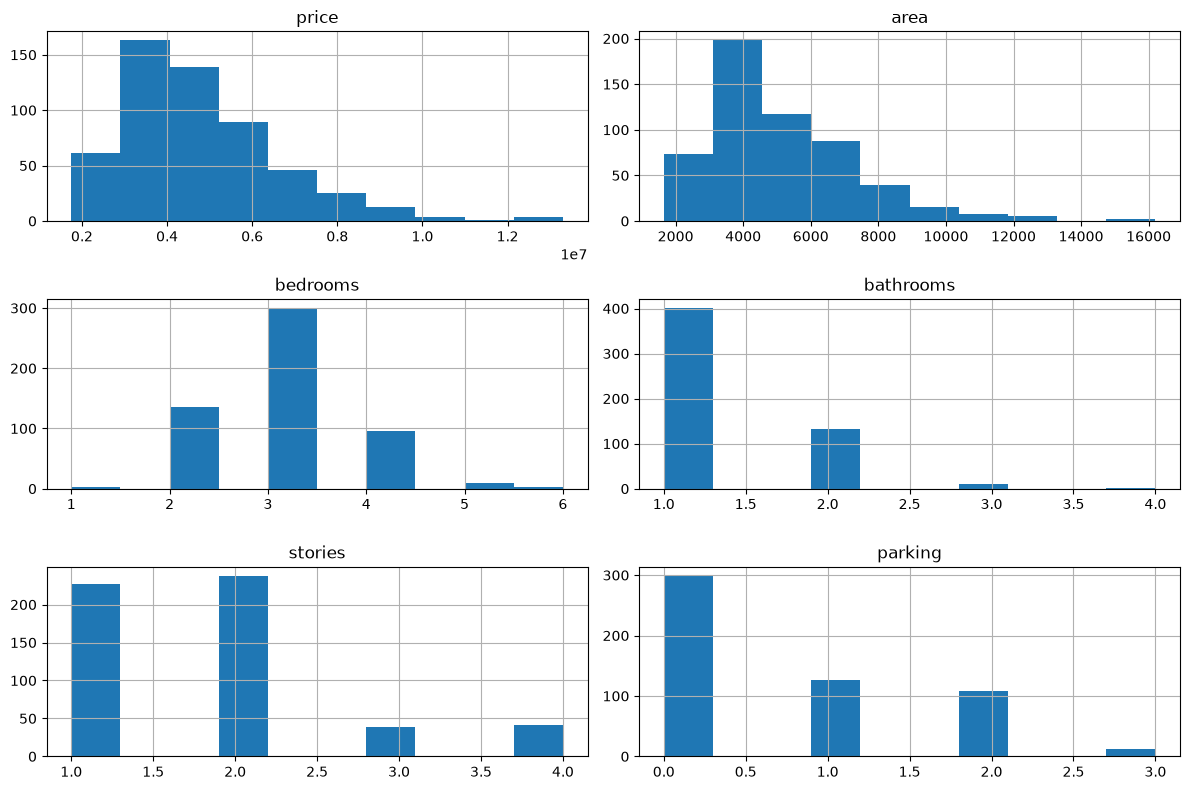

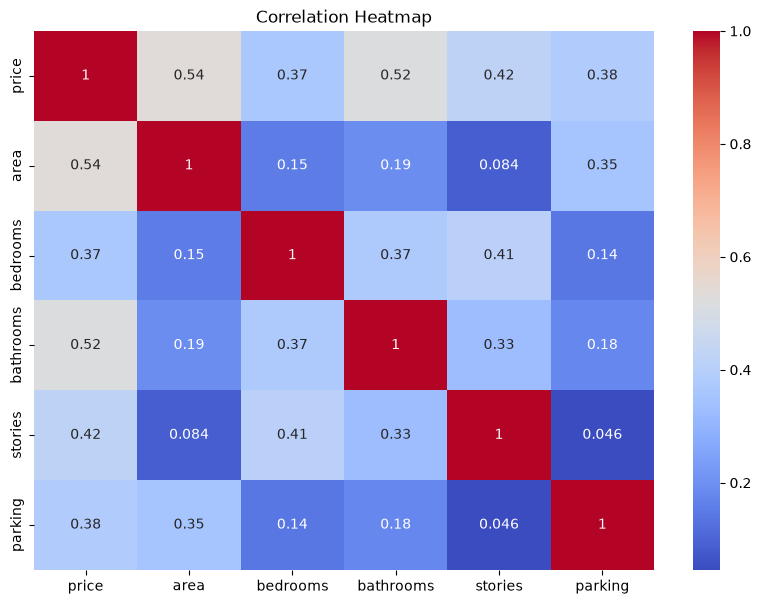

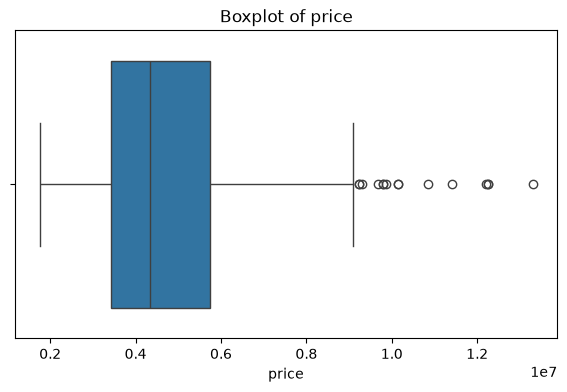

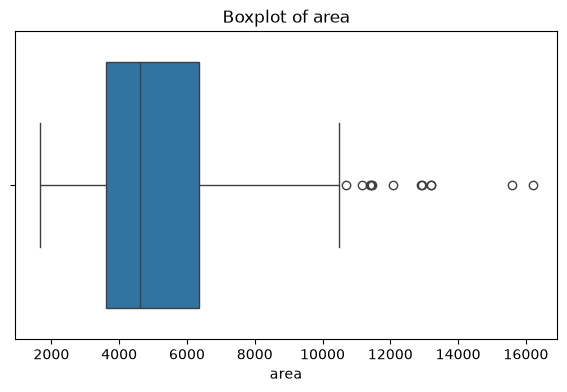

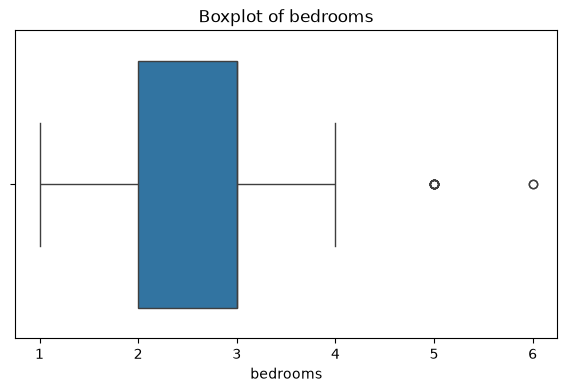

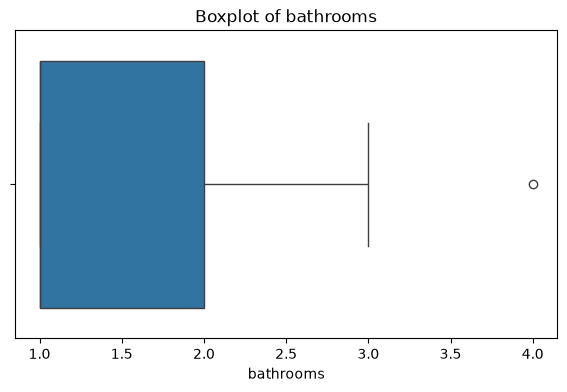

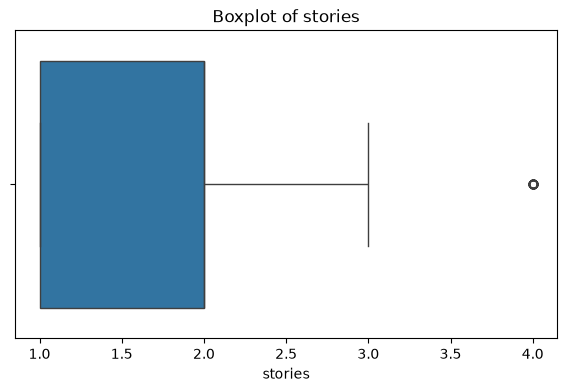

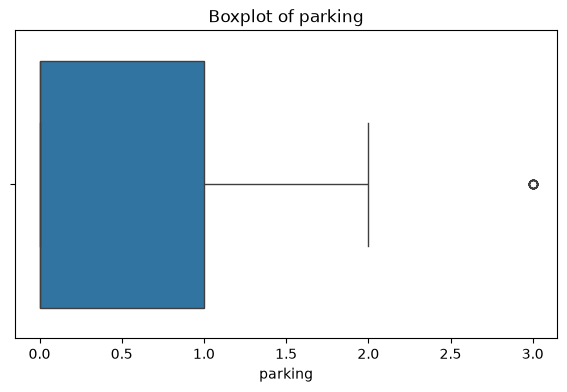

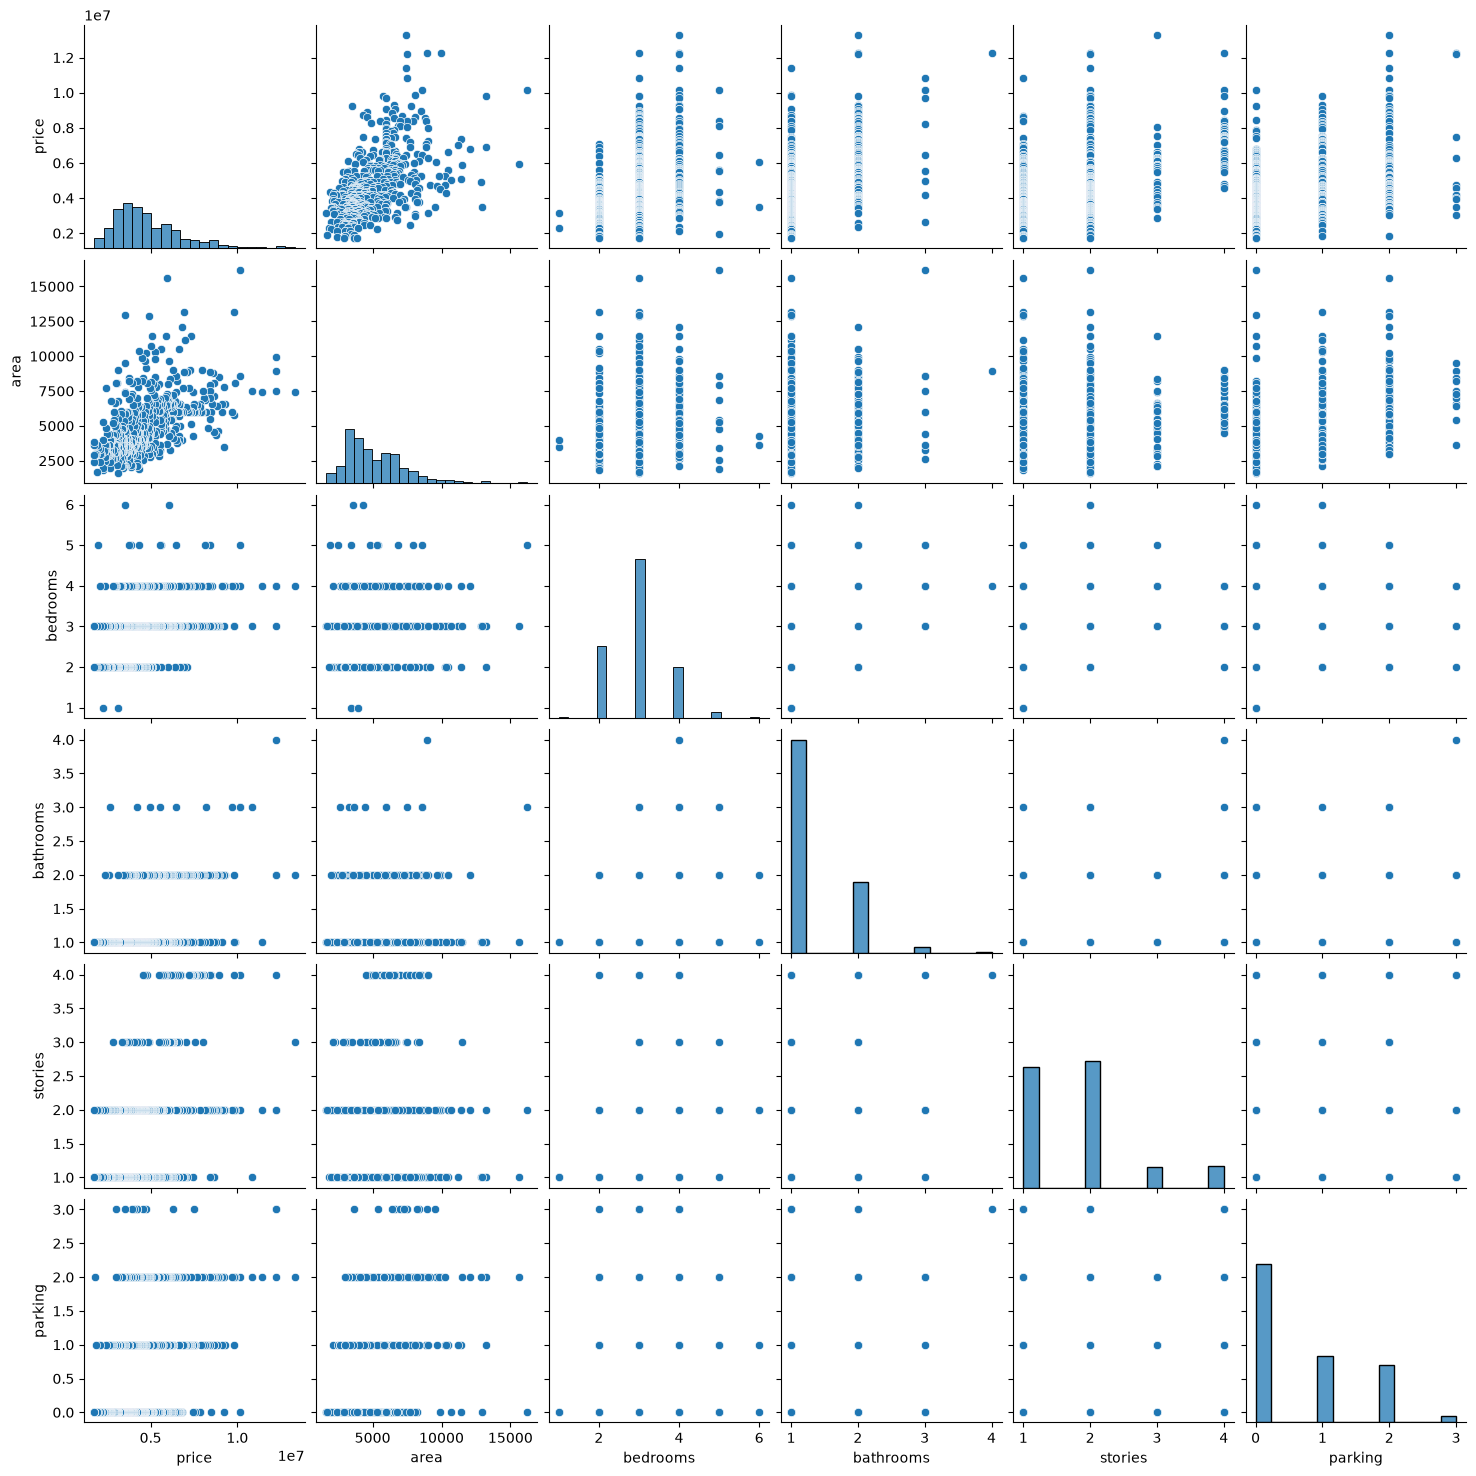

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Housing.csv")

# -----------------------------
# 1. Basic information
# -----------------------------

print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
print(df.head())

print("\nStatistical summary:")
print(df.describe())


# -----------------------------
# 2. Missing values
# -----------------------------

print("\nMissing values:")
print(df.isnull().sum())


# -----------------------------
# 3. Duplicate values
# -----------------------------

print("\nNumber of duplicates:")
print(df.duplicated().sum())

df = df.drop_duplicates()


# -----------------------------
# 4. Numerical columns
# -----------------------------

numeric_cols = df.select_dtypes(
    include=np.number
).columns

print("\nNumerical columns:")
print(numeric_cols)


# -----------------------------
# 5. Fill missing numerical values
# -----------------------------

for col in numeric_cols:
    df[col] = df[col].fillna(
        df[col].median()
    )


# -----------------------------
# 6. Categorical columns
# -----------------------------

categorical_cols = df.select_dtypes(
    include='object'
).columns

for col in categorical_cols:
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )


# -----------------------------
# 7. Histograms
# -----------------------------

df[numeric_cols].hist(figsize=(12, 8))

plt.tight_layout()
plt.show()


# -----------------------------
# 8. Correlation heatmap
# -----------------------------

plt.figure(figsize=(10, 7))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()


# -----------------------------
# 9. Box plots
# -----------------------------

for col in numeric_cols:

    plt.figure(figsize=(7, 4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Boxplot of {col}")
    plt.show()


# -----------------------------
# 10. Pairplot
# -----------------------------

sns.pairplot(
    df[numeric_cols]
)

plt.show()